In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [8]:
# Load CSV dataset
df = pd.read_csv("C:/Users/H P/OneDrive/Documents/project/heart.csv") # Change the filename if needed

# Display the first few rows
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Check for missing values
print(df.isnull().sum())

# Get summary statistics
print(df.describe())

# Check data types
print(df.info())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  

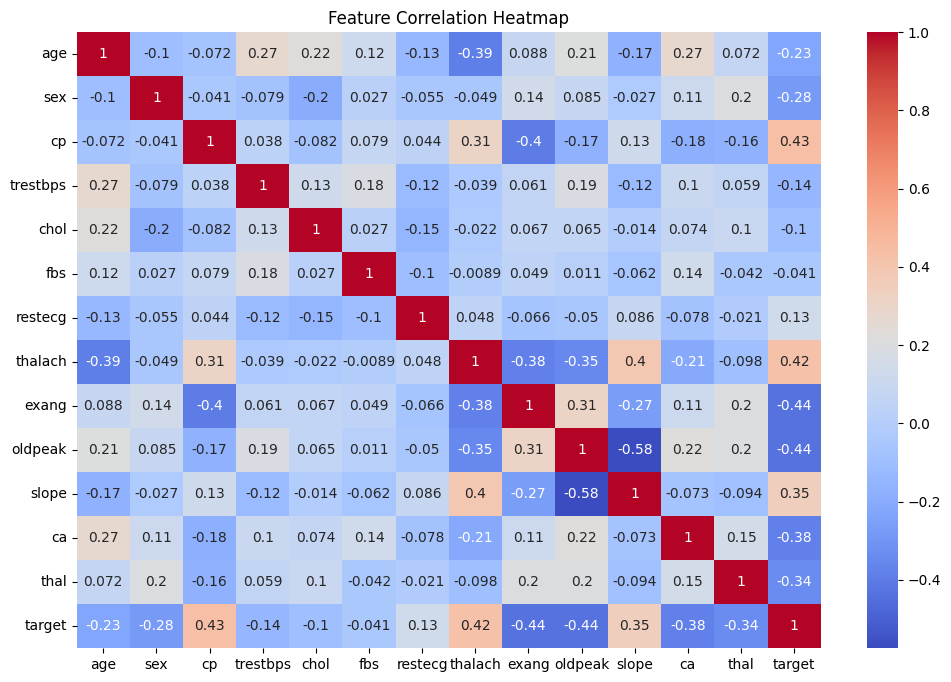

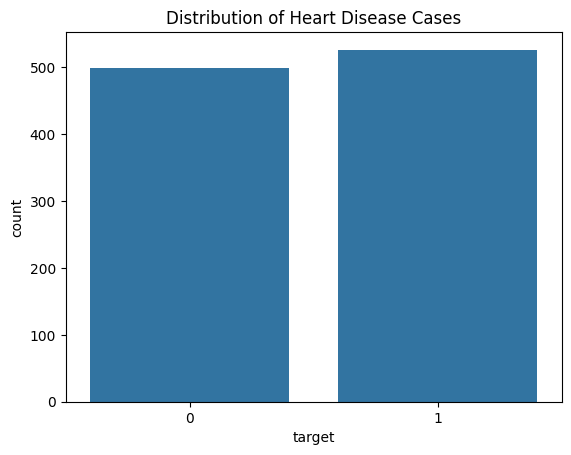

In [4]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Countplot of target variable (Assuming 'target' is the column indicating heart disease)
sns.countplot(x=df['target'])
plt.title("Distribution of Heart Disease Cases")
plt.show()


In [5]:
# Assuming 'target' is the label column
X = df.drop(columns=['target'])  # Features
y = df['target']  # Target variable

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [7]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
y_pred = model.predict(X_test_scaled)


Accuracy: 0.99
Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



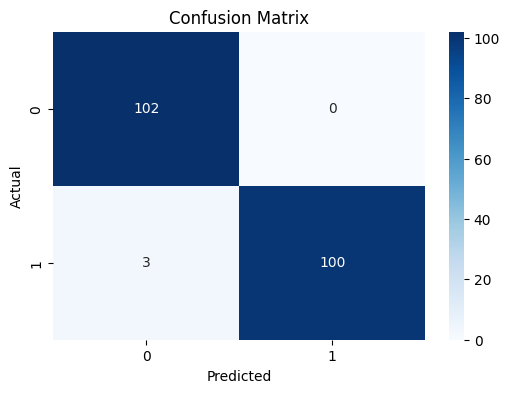

In [9]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [10]:
import joblib

# Save the trained model
joblib.dump(model, "heart_disease_model.joblib")

print("Model saved successfully as heart_disease_model.joblib")


Model saved successfully as heart_disease_model.joblib


In [11]:
import joblib
import numpy as np

# Load the saved model
model = joblib.load("heart_disease_model.joblib")

def predict_heart_disease(input_features):
    """
    Predicts whether heart disease is present or not.

    Parameters:
    input_features (list or numpy array): List of patient feature values.

    Returns:
    str: "Heart Disease Detected" or "No Heart Disease"
    """
    # Convert input to numpy array and reshape for prediction
    input_array = np.array(input_features).reshape(1, -1)

    # Predict using the loaded model
    prediction = model.predict(input_array)[0]  # 0 or 1

    # Convert prediction result to readable format
    if prediction == 1:
        return "Heart Disease Detected"
    else:
        return "No Heart Disease"

# Example test case
sample_input = [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1]  # Example patient data
result = predict_heart_disease(sample_input)

print("Prediction:", result)


Prediction: No Heart Disease
